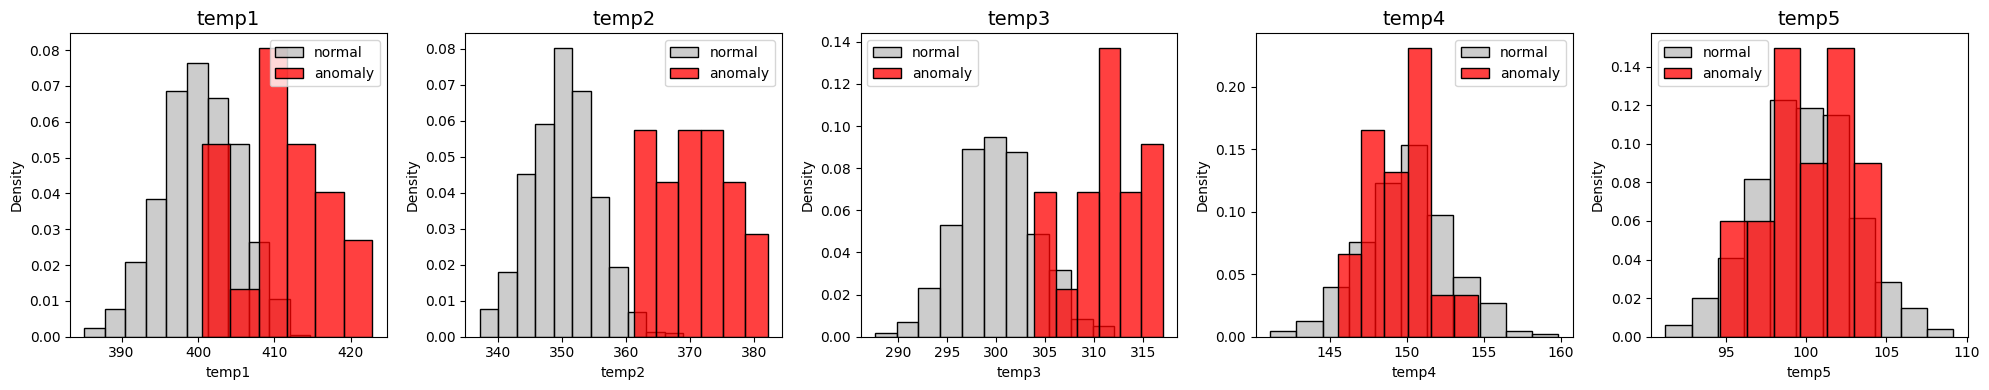

In [12]:
# ヒストグラムによる正常と異常の分離性の確認（コード2.16と同じ）
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# CSVからpandas.DataFrameにデータ読み込み
df = pd.read_csv("./datasets/ch2_dataset_train.csv")
# "label"列を削除（数値型の列のみとする）
df_val = df.drop("label", axis=1)
# 正常データのみ抽出
df_normal_val = df[df["label"] == "normal"].drop("label", axis=1)
# 異常データのみ抽出
df_anomaly_val = df[df["label"] == "anomaly"].drop("label", axis=1)
# 描画用のFigureとAxesを生成
fig, axes = plt.subplots(nrows=1, ncols=5, figsize=(20, 4))

# すべての変数をループで走査
for i, colname in enumerate(df_normal_val.columns):
    # 正常データのヒストグラム描画
    sns.histplot(data=df_normal_val[colname], bins="sturges",
                 color="#bbbbbb", ax=axes[i],
                 stat="density", label="normal")
    # 異常データのヒストグラム描画
    sns.histplot(data=df_anomaly_val[colname], bins="sturges",
                 color="#ff0000", ax=axes[i],
                 stat="density", label="anomaly")
    # 凡例を追加
    axes[i].legend()
    # 変数名を図のタイトルとして追加
    axes[i].set_title(colname, fontsize=14)

plt.tight_layout()
plt.show()

In [13]:
import pandas as pd
import numpy as np
from scipy import stats

# Load the training data
df = pd.read_csv('./datasets/ch2_dataset_train.csv')

# Drop rows with missing values in 'temp2' and 'temp1'
df_dropna = df.dropna(subset=['temp2', 'temp1'])
# print(df_dropna)

# Filter the data to include only rows where the label is 'normal'
df_normal = df_dropna[df_dropna['label'] == 'normal']
# Extract the features 'temp2' and 'temp1' as a NumPy array
X_train = df_normal[['temp2', 'temp1']].to_numpy()

# Calculate the mean of the training data
mu = np.mean(X_train, axis=0)
# print(mu)

# Calculate the covariance matrix of the training data
Sigma = np.cov(X_train.T, ddof=0)

TARGET_FP_RATE = 0.0027 # Target false positive rate (0.27%)
n_features = X_train.shape[1] # Number of features (2 in this case)
# Calculate the threshold using the chi-squared distribution
a_th = stats.chi2.ppf(1 - TARGET_FP_RATE, df=n_features)

print(f"mu: {mu}")
print(f"Sigma: {Sigma}")
print(f"a_th: {a_th}")

mu: [350.23771153 400.21552883]
Sigma: [[26.04088919 14.52874949]
 [14.52874949 24.58401158]]
a_th: 11.82900701194368


In [14]:

MU = mu
SIGMA = Sigma
A_TH = a_th

df_inference = pd.read_csv('./datasets/ch2_dataset_inference2.csv')
# Drop rows with missing values in 'temp2' and 'temp1'
df_inference_dropna = df_inference.dropna(subset=['temp2', 'temp1'])
# Extract the features 'temp2' and 'temp1' as a NumPy array
X_inference = df_inference_dropna[['temp2', 'temp1']].to_numpy()

# Calculate the inverse of the covariance matrix
Sigma_inv = np.linalg.inv(SIGMA)

# Center the inference data by subtracting the mean ( x - mu )
X_dev=  (X_inference - np.array(MU)).T 
Dev_Sigma_inv = X_dev.T @ Sigma_inv
anomaly_scores = np.sum(Dev_Sigma_inv * X_dev.T, axis=1)

# Classify as anomaly if the score exceeds the threshold
pred = np.where(anomaly_scores > A_TH, 'anomaly', 'normal')
print(pred)



['normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal'
 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal'
 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal'
 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal'
 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal'
 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal'
 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal'
 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal'
 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal'
 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal'
 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal'
 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal'
 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal'
 'normal' 'normal' 'normal' 'normal' 'normal' 'norm

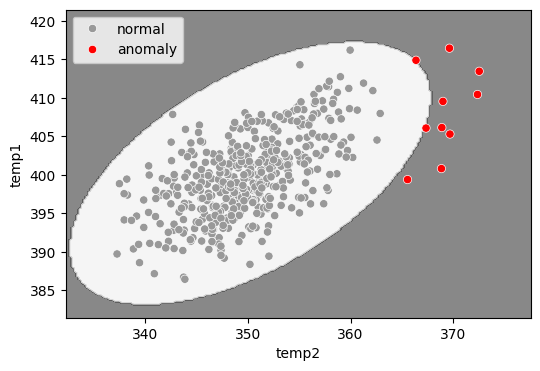

In [16]:
# 推論結果の決定境界を可視化
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

# 異常度と異常判定をDataFrameに列として追加
df_inference_dropna['anomaly_score'] = anomaly_scores
df_inference_dropna['prediction'] = pred
# 描画用のFigureとAxesを生成
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6, 4))

###### 正常と異常の範囲を色分け ######
# (x1,x2)格子点を作成（'temp2'をx1としていることに注意）
x1_grid = np.linspace(df_inference_dropna['temp2'].min()-5,
                      df_inference_dropna['temp2'].max()+5, 200)
x2_grid = np.linspace(df_inference_dropna['temp1'].min()-5,
                      df_inference_dropna['temp1'].max()+5, 200)
X1, X2 = np.meshgrid(x1_grid, x2_grid)
X_grid = np.c_[X1.ravel(), X2.ravel()]
# 異常度を算出（式6.53に従う）
X_dev_grid = (X_grid-np.array(MU)).T  # 推論データと平均ベクトルとの差（x-μ）
Dev_Sigma_grid = X_dev_grid.T @ Sigma_inv  # (x-μ)^T * Σ^-1
anomaly_scores_grid = np.sum(np.multiply(Dev_Sigma_grid, X_dev_grid.T), axis=1)
# しきい値判定
pred_grid = np.where(anomaly_scores_grid > A_TH, 0, 1)
# 正常と異常の境界をプロット
pred_pivot = pred_grid.reshape(X1.shape)
ax.contourf(X1, X2, pred_pivot,
            cmap=cm.gray, alpha=0.5)

###### 各データを散布図としてプロット ######
sns.scatterplot(data=df_inference_dropna, x='temp2', y='temp1',
    hue='label', palette=['#999999', "#FF0000"],
    ax=ax
)
# 凡例を追加
ax.legend()
# グラフを表示
plt.show()

['normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal'
 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal'
 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal'
 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal'
 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal'
 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal'
 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal'
 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal'
 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal'
 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal'
 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal'
 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal'
 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal'
 'normal' 'normal' 'normal' 'normal' 'normal' 'norm

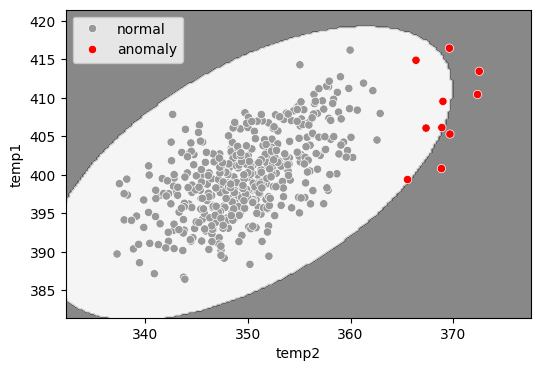

In [18]:
TARGET_FP_RATE = 0.0027 # Target false positive rate (0.27%)

Sigma_inv = np.linalg.inv(Sigma)
X_dev=  (X_inference - np.array(MU)).T 
Dev_Sigma_inv = X_dev.T @ Sigma_inv
anomaly_scores_train = np.sum(np.multiply(Dev_Sigma_inv, X_dev.T), axis=1)

params = stats.chi2.fit(anomaly_scores_train, floc=0)
df = params[0]
scale = params[2]

a_th = stats.chi2.ppf(1 - TARGET_FP_RATE, df=df, scale=scale)

MU = mu
SIGMA = Sigma
A_TH = a_th

df_inference = pd.read_csv('./datasets/ch2_dataset_inference2.csv')
# Drop rows with missing values in 'temp2' and 'temp1'
df_inference_dropna = df_inference.dropna(subset=['temp2', 'temp1'])
# Extract the features 'temp2' and 'temp1' as a NumPy array
X_inference = df_inference_dropna[['temp2', 'temp1']].to_numpy()

# Calculate the inverse of the covariance matrix
Sigma_inv = np.linalg.inv(SIGMA)

# Center the inference data by subtracting the mean ( x - mu )
X_dev=  (X_inference - np.array(MU)).T 
Dev_Sigma_inv = X_dev.T @ Sigma_inv
anomaly_scores = np.sum(Dev_Sigma_inv * X_dev.T, axis=1)

# Classify as anomaly if the score exceeds the threshold
pred = np.where(anomaly_scores > A_TH, 'anomaly', 'normal')
print(pred)

# 推論結果の決定境界を可視化
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

# 異常度と異常判定をDataFrameに列として追加
df_inference_dropna['anomaly_score'] = anomaly_scores
df_inference_dropna['prediction'] = pred
# 描画用のFigureとAxesを生成
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6, 4))

###### 正常と異常の範囲を色分け ######
# (x1,x2)格子点を作成（'temp2'をx1としていることに注意）
x1_grid = np.linspace(df_inference_dropna['temp2'].min()-5,
                      df_inference_dropna['temp2'].max()+5, 200)
x2_grid = np.linspace(df_inference_dropna['temp1'].min()-5,
                      df_inference_dropna['temp1'].max()+5, 200)
X1, X2 = np.meshgrid(x1_grid, x2_grid)
X_grid = np.c_[X1.ravel(), X2.ravel()]
# 異常度を算出（式6.53に従う）
X_dev_grid = (X_grid-np.array(MU)).T  # 推論データと平均ベクトルとの差（x-μ）
Dev_Sigma_grid = X_dev_grid.T @ Sigma_inv  # (x-μ)^T * Σ^-1
anomaly_scores_grid = np.sum(np.multiply(Dev_Sigma_grid, X_dev_grid.T), axis=1)
# しきい値判定
pred_grid = np.where(anomaly_scores_grid > A_TH, 0, 1)
# 正常と異常の境界をプロット
pred_pivot = pred_grid.reshape(X1.shape)
ax.contourf(X1, X2, pred_pivot,
            cmap=cm.gray, alpha=0.5)

###### 各データを散布図としてプロット ######
sns.scatterplot(data=df_inference_dropna, x='temp2', y='temp1',
    hue='label', palette=['#999999', "#FF0000"],
    ax=ax
)
# 凡例を追加
ax.legend()
# グラフを表示
plt.show()